# Problem Statement : Mashroom Classification
### Safe to eat or deadly poison?

### Dataset Information: (classes: edible=e, poisonous=p)

- **cap-shape**: bell=b,conical=c,convex=x,flat=f, knobbed=k,sunken=s

- **cap-surface**: fibrous=f,grooves=g,scaly=y,smooth=s

- **cap-color**: brown=n,buff=b,cinnamon=c,gray=g,green=r,pink=p,purple=u,red=e,white=w,yellow=y

- **bruises**: bruises=t,no=f

- **odor**: almond=a,anise=l,creosote=c,fishy=y,foul=f,musty=m,none=n,pungent=p,spicy=s

- **gill-attachment**: attached=a,descending=d,free=f,notched=n

- **gill-spacing**: close=c,crowded=w,distant=d

- **gill-size**: broad=b,narrow=n

- **gill-color**: black=k,brown=n,buff=b,chocolate=h,gray=g, green=r,orange=o,pink=p,purple=u,red=e,white=w,yellow=y

- **stalk-shape**: enlarging=e,tapering=t

- **stalk-root**: bulbous=b,club=c,cup=u,equal=e,rhizomorphs=z,rooted=r,missing=?

- **stalk-surface-above-ring**: fibrous=f,scaly=y,silky=k,smooth=s

- **stalk-surface-below-ring**: fibrous=f,scaly=y,silky=k,smooth=s

- **stalk-color-above-ring**: brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y

- **stalk-color-below-ring**: brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y

- **veil-type**: partial=p,universal=u

- **veil-color**: brown=n,orange=o,white=w,yellow=y

- **ring-number**: none=n,one=o,two=t

- **ring-type**: cobwebby=c,evanescent=e,flaring=f,large=l,none=n,pendant=p,sheathing=s,zone=z

- **spore-print-color**: black=k,brown=n,buff=b,chocolate=h,green=r,orange=o,purple=u,white=w,yellow=y

- **population**: abundant=a,clustered=c,numerous=n,scattered=s,several=v,solitary=y

- **habitat**: grasses=g,leaves=l,meadows=m,paths=p,urban=u,waste=w,woods=d

In [4]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import train_test_split 

from sklearn.svm import SVC 
import warnings 
warnings.filterwarnings('ignore')

In [6]:
data = pd.read_csv('/Users/vydhyamvishnusai/MUSHOROOM_SVM_MODEL/mushrooms.csv')
data.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


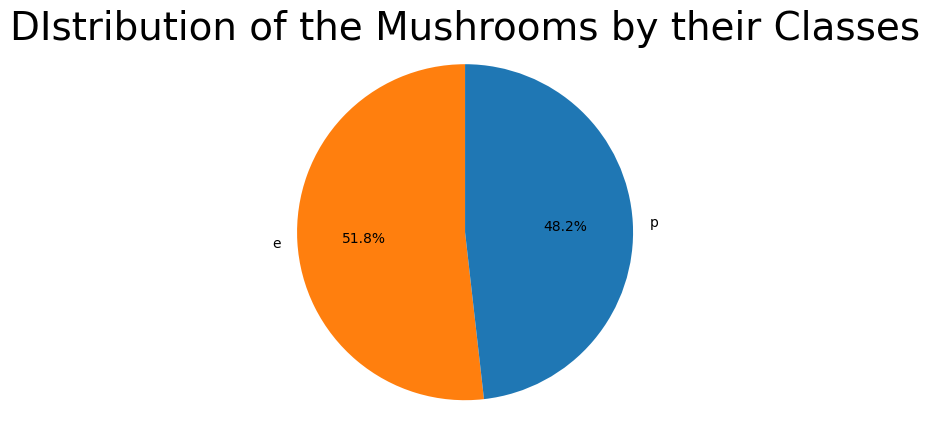

In [19]:
counts = data['class'].value_counts()
plt.pie(counts,labels = counts.index,autopct = '%1.1f%%',   colors = ['#ff7f0e','#1f77b4'], startangle = 90 )
plt.title('DIstribution of the Mushrooms by their Classes', fontsize = 28)
plt.axis('equal')
plt.show()

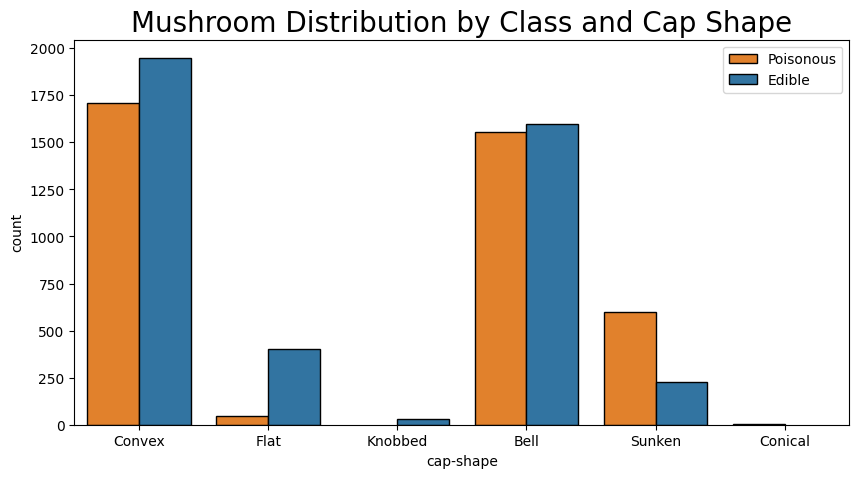

In [25]:
plt.figure(figsize = (10,5))
splot = sns.countplot(data = data, x = 'cap-shape',hue = 'class',  palette =  ['#ff7f0e','#1f77b4'], edgecolor = 'black')
splot.set_xticklabels(['Convex','Flat','Knobbed', 'Bell', 'Sunken', 'Conical'])
plt.legend(labels = ['Poisonous', 'Edible'])
plt.title('Mushroom Distribution by Class and Cap Shape', fontsize = 20) 
plt.show()

**Cap Surfaces**

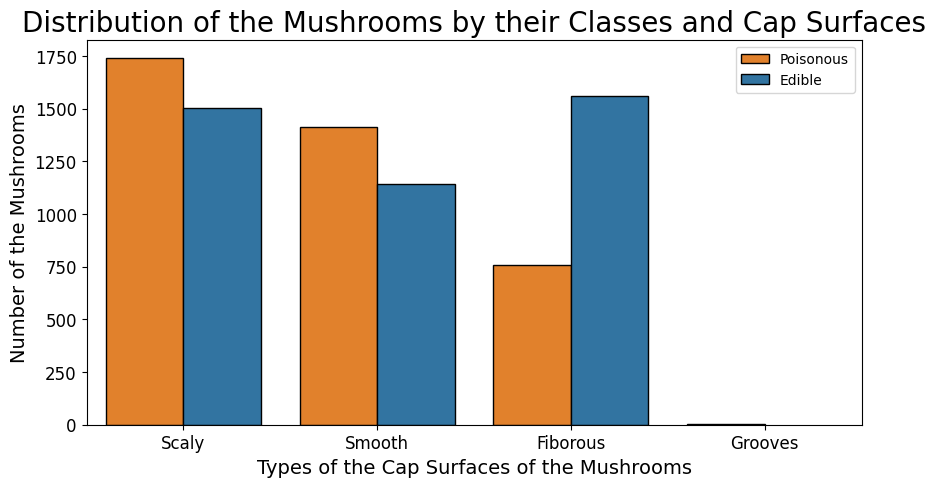

In [29]:
plt.figure(figsize = (10,5))
splot = sns.countplot(data = data, x = 'cap-surface',hue = 'class',order = data['cap-surface'].value_counts().index,  palette =  ['#ff7f0e','#1f77b4'], edgecolor = 'black')

splot.set_xticklabels(['Scaly','Smooth','Fiborous', 'Grooves'])
plt.legend(labels = ['Poisonous', 'Edible'] ,loc = 'upper right')
plt.ylabel('Number of the Mushrooms', fontsize = 14) 
plt.xlabel('Types of the Cap Surfaces of the Mushrooms' , fontsize = 14)
plt.xticks(fontsize=12)
plt.yticks(fontsize = 12)
plt.title('Distribution of the Mushrooms by their Classes and Cap Surfaces', fontsize = 20)
plt.show()
           

**Cap Colors**

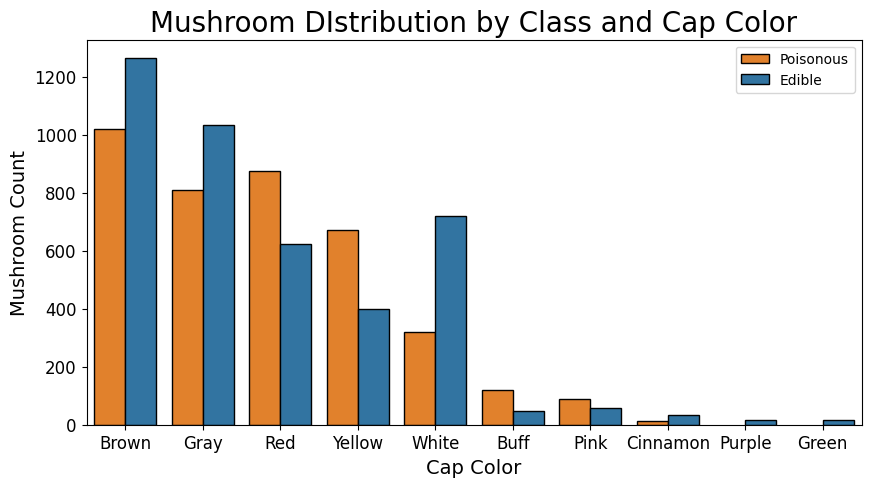

In [30]:
plt.figure(figsize = (10,5))
splot = sns.countplot(data = data, x = 'cap-color',hue = 'class',order = data['cap-color'].value_counts().index,  palette =  ['#ff7f0e','#1f77b4'], edgecolor = 'black')

splot.set_xticklabels(['Brown', 'Gray', 'Red', 'Yellow', 'White', 'Buff', 'Pink', 'Cinnamon', 'Purple', 'Green'])
plt.legend(labels = ['Poisonous', 'Edible'] ,loc = 'upper right')
plt.ylabel('Mushroom Count', fontsize = 14) 
plt.xlabel('Cap Color' , fontsize = 14)
plt.xticks(fontsize=12)
plt.yticks(fontsize = 12)
plt.title('Mushroom DIstribution by Class and Cap Color', fontsize = 20)
plt.show()

**Bruises**

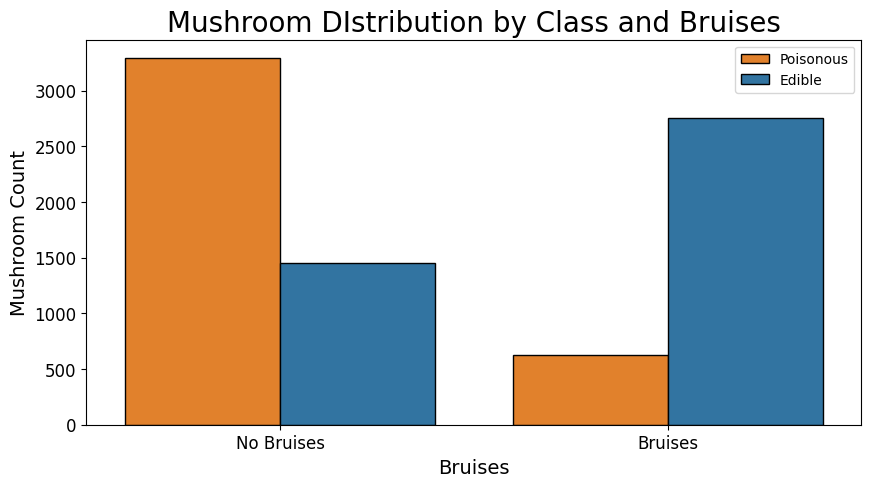

In [31]:
plt.figure(figsize = (10,5))
splot = sns.countplot(data = data, x = 'bruises',hue = 'class',order = data['bruises'].value_counts().index,  palette =  ['#ff7f0e','#1f77b4'], edgecolor = 'black')

splot.set_xticklabels(['No Bruises', 'Bruises' ])
plt.legend(labels = ['Poisonous', 'Edible'] ,loc = 'upper right')
plt.ylabel('Mushroom Count', fontsize = 14) 
plt.xlabel('Bruises' , fontsize = 14)
plt.xticks(fontsize=12)
plt.yticks(fontsize = 12)
plt.title('Mushroom DIstribution by Class and Bruises', fontsize = 20)
plt.show()

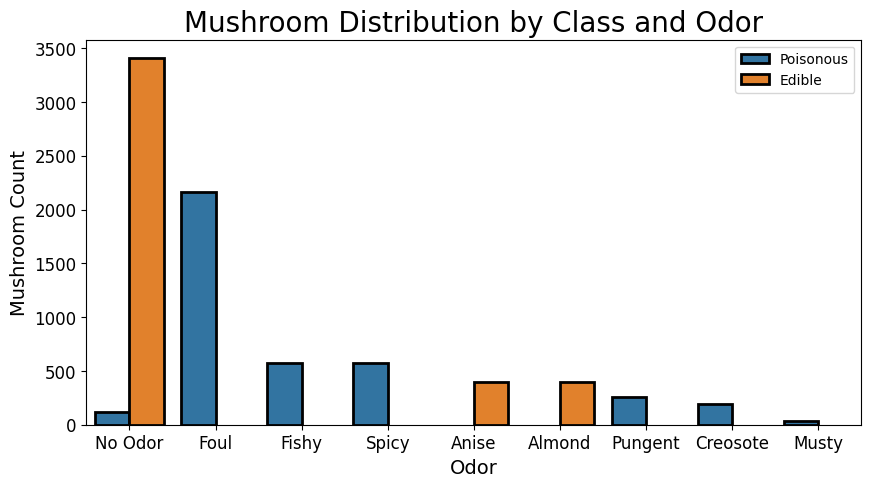

In [33]:
plt.figure(figsize=(10, 5))
splot = sns.countplot(data=data, x='odor', hue='class',order=data['odor'].value_counts().index,palette=['#1f77b4', '#ff7f0e'], edgecolor='black', linewidth=2)
splot.set_xticklabels(['No Odor', 'Foul', 'Fishy', 'Spicy', 'Anise', 'Almond', 'Pungent', 'Creosote', 'Musty'])
plt.legend(['Poisonous', 'Edible'], loc='upper right')
plt.ylabel('Mushroom Count', fontsize=14)
plt.xlabel('Odor', fontsize=14)
plt.title('Mushroom Distribution by Class and Odor', fontsize=20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

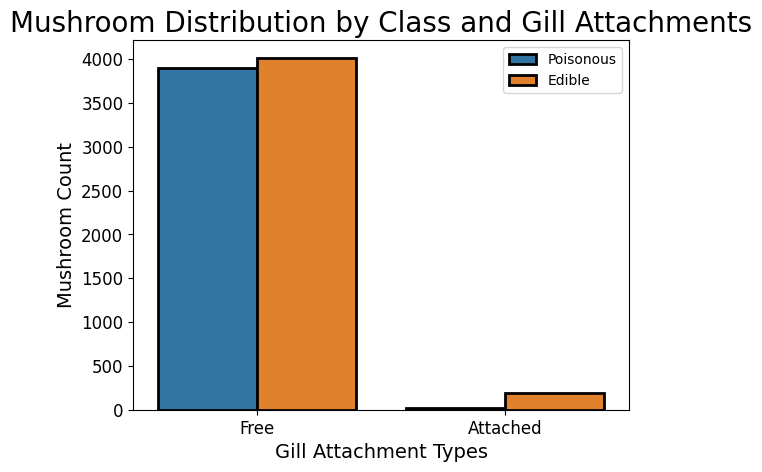

In [34]:
splot = sns.countplot(data=data, x='gill-attachment', hue='class',order=data['gill-attachment'].value_counts().index,palette=['#1f77b4', '#ff7f0e'], edgecolor='black', linewidth=2)
splot.set_xticklabels(['Free', 'Attached'])
plt.legend(['Poisonous', 'Edible'], loc='upper right')
plt.ylabel('Mushroom Count', fontsize=14)
plt.xlabel('Gill Attachment Types', fontsize=14)
plt.title('Mushroom Distribution by Class and Gill Attachments', fontsize=20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


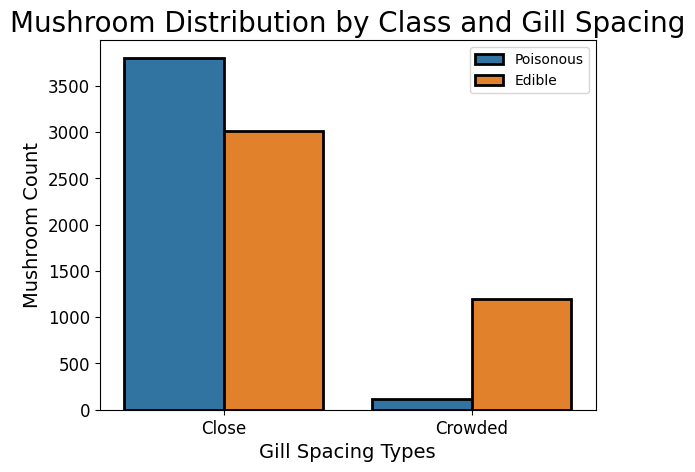

In [35]:
splot = sns.countplot(data=data, x='gill-spacing', hue='class',order=data['gill-spacing'].value_counts().index,palette=['#1f77b4', '#ff7f0e'], edgecolor='black', linewidth=2)
splot.set_xticklabels(['Close', 'Crowded'])
plt.legend(['Poisonous', 'Edible'], loc='upper right')
plt.ylabel('Mushroom Count', fontsize=14)
plt.xlabel('Gill Spacing Types', fontsize=14)
plt.title('Mushroom Distribution by Class and Gill Spacing', fontsize=20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


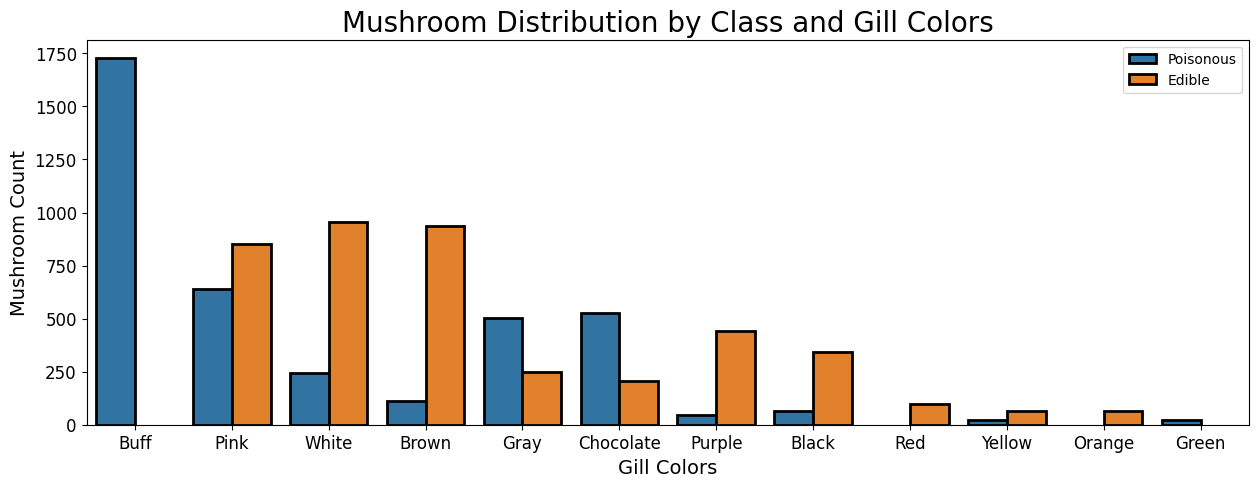

In [37]:
plt.figure(figsize=(15, 5))
splot = sns.countplot(data=data, x='gill-color', hue='class',order=data['gill-color'].value_counts().index,palette=['#1f77b4', '#ff7f0e'], edgecolor='black', linewidth=2)
splot.set_xticklabels(['Buff', 'Pink', 'White', 'Brown', 'Gray', 'Chocolate', 'Purple', 'Black', 'Red', 'Yellow', 'Orange', 'Green'])
plt.legend(['Poisonous', 'Edible'], loc='upper right')
plt.ylabel('Mushroom Count', fontsize=14)
plt.xlabel('Gill Colors', fontsize=14)
plt.title('Mushroom Distribution by Class and Gill Colors', fontsize=20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

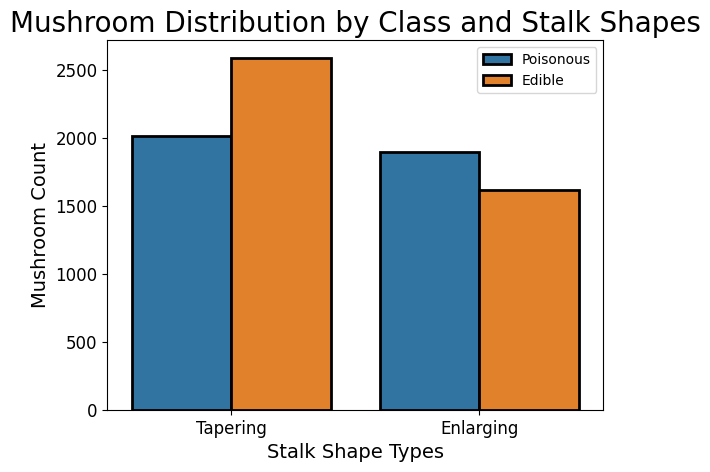

In [38]:
plt.plot(figsize=(10, 5))
splot = sns.countplot(data=data, x='stalk-shape', hue='class',order=data['stalk-shape'].value_counts().index,palette=['#1f77b4', '#ff7f0e'], edgecolor='black', linewidth=2)
splot.set_xticklabels(['Tapering', 'Enlarging'])
plt.legend(['Poisonous', 'Edible'], loc='upper right')
plt.ylabel('Mushroom Count', fontsize=14)
plt.xlabel('Stalk Shape Types', fontsize=14)
plt.title('Mushroom Distribution by Class and Stalk Shapes', fontsize=20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

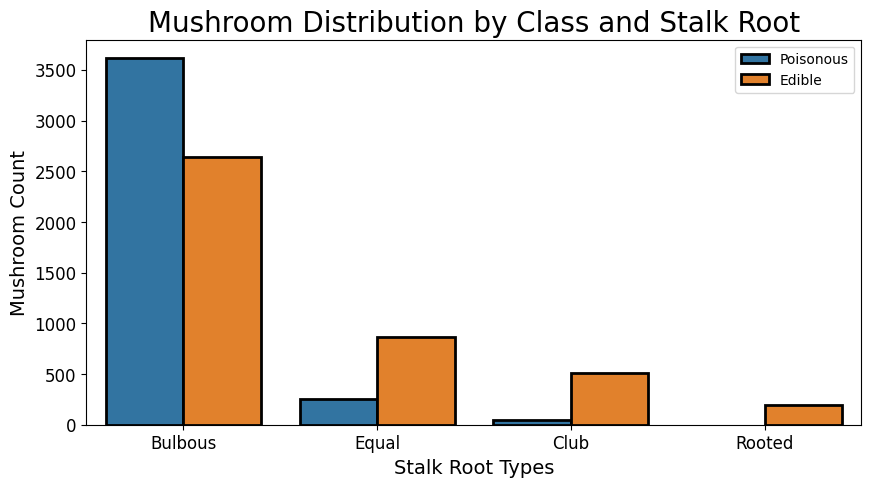

In [41]:
# Fill missing values in 'stalk-root' with the most frequent object 'b'
data = data.replace(['?'], 'b')
plt.figure(figsize=(10, 5))
splot = sns.countplot(data=data, x='stalk-root', hue='class',order=data['stalk-root'].value_counts().index,palette=['#1f77b4', '#ff7f0e'], edgecolor='black', linewidth=2)
splot.set_xticklabels(['Bulbous', 'Equal', 'Club', 'Rooted'])
plt.legend(['Poisonous', 'Edible'], loc='upper right')
plt.ylabel('Mushroom Count', fontsize=14)
plt.xlabel('Stalk Root Types', fontsize=14)
plt.title('Mushroom Distribution by Class and Stalk Root', fontsize=20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12);

Text(0.5, 1.0, 'Distribution of the Mushrooms by their Classes vs Stalk Surfaces Above Ring')

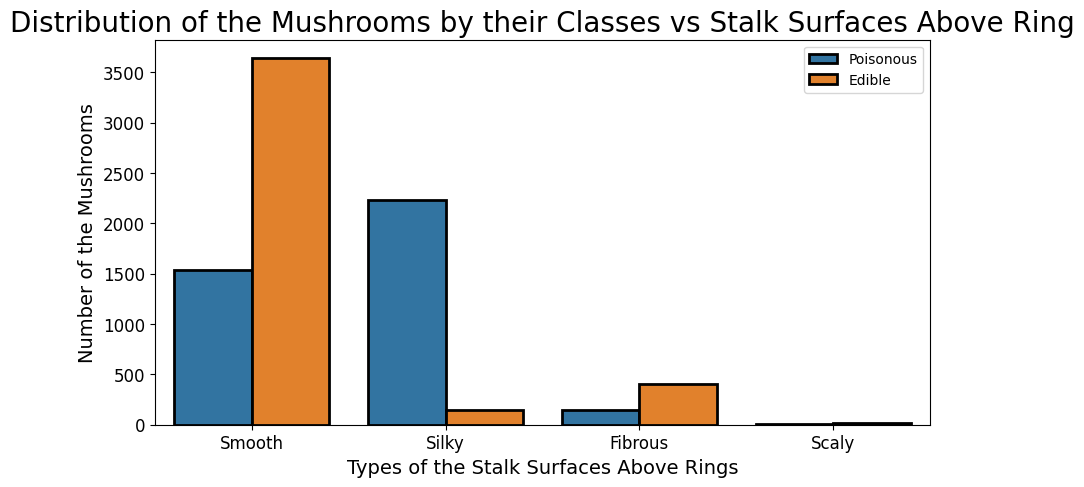

In [43]:
plt.figure(figsize=(10, 5))
splot = sns.countplot(data=data, x='stalk-surface-above-ring',
                      hue='class',
                      order=data['stalk-surface-above-ring'].value_counts().index,
                      palette=['#1f77b4', '#ff7f0e'],
                      edgecolor=(0, 0, 0),
                      linewidth=2)

splot.set_xticklabels(['Smooth', 'Silky', 'Fibrous', 'Scaly'])

plt.legend(['Poisonous', 'Edible'], loc='upper right')
plt.ylabel('Number of the Mushrooms', fontsize=14)
plt.xlabel('Types of the Stalk Surfaces Above Rings', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title('Distribution of the Mushrooms by their Classes vs Stalk Surfaces Above Ring', fontsize=20)


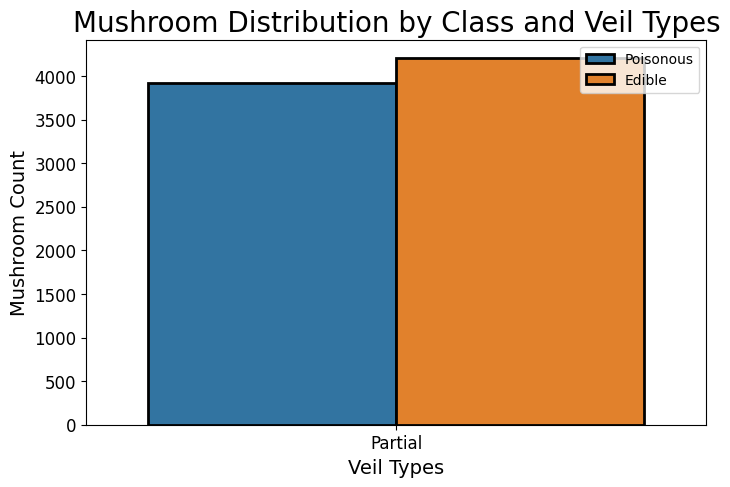

In [44]:
plt.figure(figsize=(8, 5))
splot = sns.countplot(data=data, x='veil-type', hue='class',
                      order=data['veil-type'].value_counts().index,
                      palette=['#1f77b4', '#ff7f0e'], edgecolor='black', linewidth=2)

splot.set_xticklabels(['Partial'])

plt.legend(['Poisonous', 'Edible'], loc='upper right')
plt.ylabel('Mushroom Count', fontsize=14)
plt.xlabel('Veil Types', fontsize=14)
plt.title('Mushroom Distribution by Class and Veil Types', fontsize=20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12);

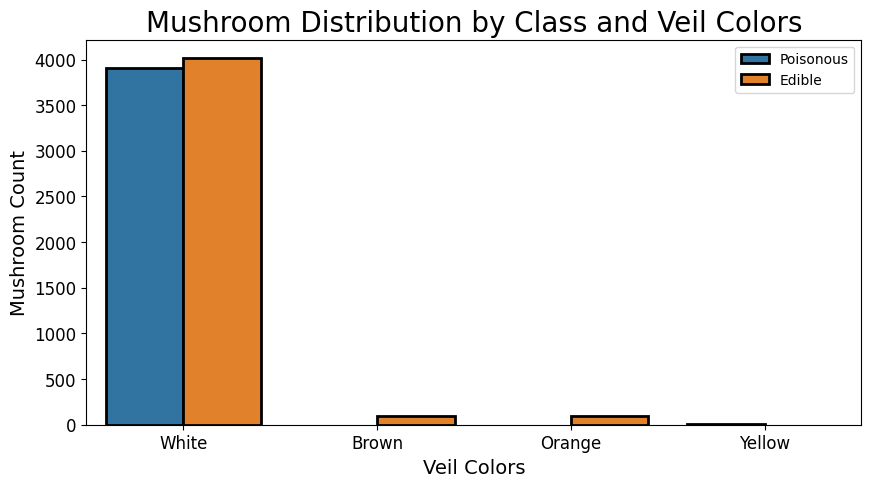

In [45]:
plt.figure(figsize=(10, 5))
splot = sns.countplot(data=data, x='veil-color', hue='class',
                      order=data['veil-color'].value_counts().index,
                      palette=['#1f77b4', '#ff7f0e'], edgecolor='black', linewidth=2)

splot.set_xticklabels(['White', 'Brown', 'Orange', 'Yellow'])

plt.legend(['Poisonous', 'Edible'], loc='upper right')
plt.ylabel('Mushroom Count', fontsize=14)
plt.xlabel('Veil Colors', fontsize=14)
plt.title('Mushroom Distribution by Class and Veil Colors', fontsize=20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12);

In [49]:
!pip install plotly


In [50]:
import plotly.figure_factory as ff

x = ['None', 'One', 'Two']
y = ['Poisonous', 'Edible']
z = [
    [data[data['class'] == 'p']['ring-number'].value_counts().get(i, 0) for i in range(3)],
    [data[data['class'] == 'e']['ring-number'].value_counts().get(i, 0) for i in range(3)]
]

fig = ff.create_annotated_heatmap(z, x=x, y=y, colorscale='Viridis')
fig.update_layout(
    title_text='Heatmap of Mushrooms by Classes vs Number of Rings',
    title_x=0.5,
    title_font=dict(size=22),
    xaxis=dict(tickfont=dict(size=15)),
    yaxis=dict(tickfont=dict(size=15))
)
fig.show()

In [51]:
import plotly.figure_factory as ff
x = ['None', 'One', 'Two']
y = ['Poisonous', 'Edible']
z = [
    [data[data['class'] == 'p']['ring-number'].value_counts().get(i, 0) for i in range(3)],
    [data[data['class'] == 'e']['ring-number'].value_counts().get(i, 0) for i in range(3)]
]
fig = ff.create_annotated_heatmap(z, x=x, y=y, colorscale='Viridis')
fig.update_layout(
    title_text='Heatmap of Mushrooms by Classes vs Number of Rings',
    title_x=0.5,
    title_font=dict(size=22),
    xaxis=dict(tickfont=dict(size=15)),
    yaxis=dict(tickfont=dict(size=15))
)
fig.show()

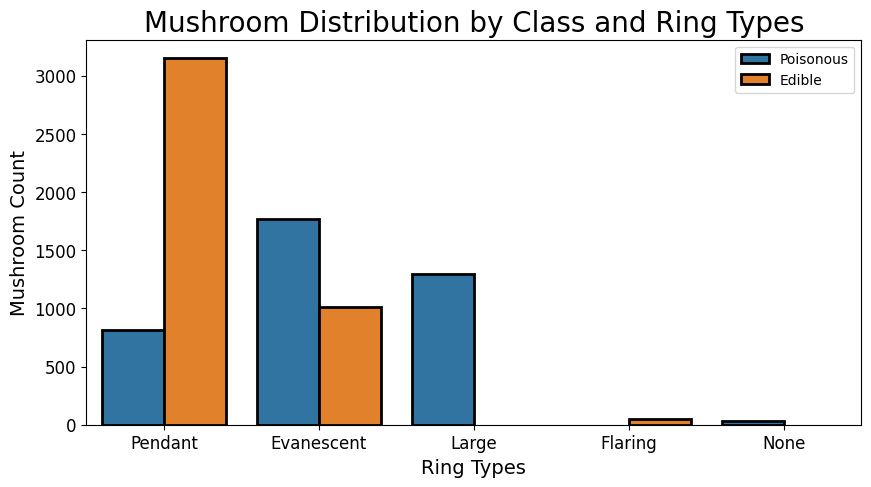

In [52]:
plt.figure(figsize=(10, 5))
splot = sns.countplot(data=data, x='ring-type', hue='class',
                      order=data['ring-type'].value_counts().index,
                      palette=['#1f77b4', '#ff7f0e'], edgecolor='black', linewidth=2)

splot.set_xticklabels(['Pendant', 'Evanescent', 'Large', 'Flaring', 'None'])

plt.legend(['Poisonous', 'Edible'], loc='upper right')
plt.ylabel('Mushroom Count', fontsize=14)
plt.xlabel('Ring Types', fontsize=14)
plt.title('Mushroom Distribution by Class and Ring Types', fontsize=20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12);

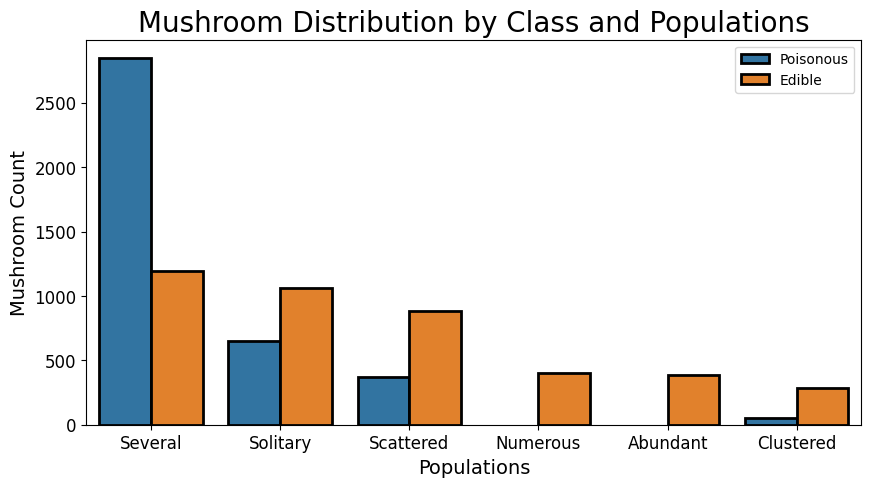

In [53]:
plt.figure(figsize=(10, 5))
splot = sns.countplot(data=data, x='population', hue='class',
                      order=data['population'].value_counts().index,
                      palette=['#1f77b4', '#ff7f0e'], edgecolor='black', linewidth=2)

splot.set_xticklabels(['Several', 'Solitary', 'Scattered', 'Numerous', 'Abundant', 'Clustered'])

plt.legend(['Poisonous', 'Edible'], loc='upper right')
plt.ylabel('Mushroom Count', fontsize=14)
plt.xlabel('Populations', fontsize=14)
plt.title('Mushroom Distribution by Class and Populations', fontsize=20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12);

Text(0.5, 1.0, 'Distribution of the Mushrooms by their Classes vs Populations')

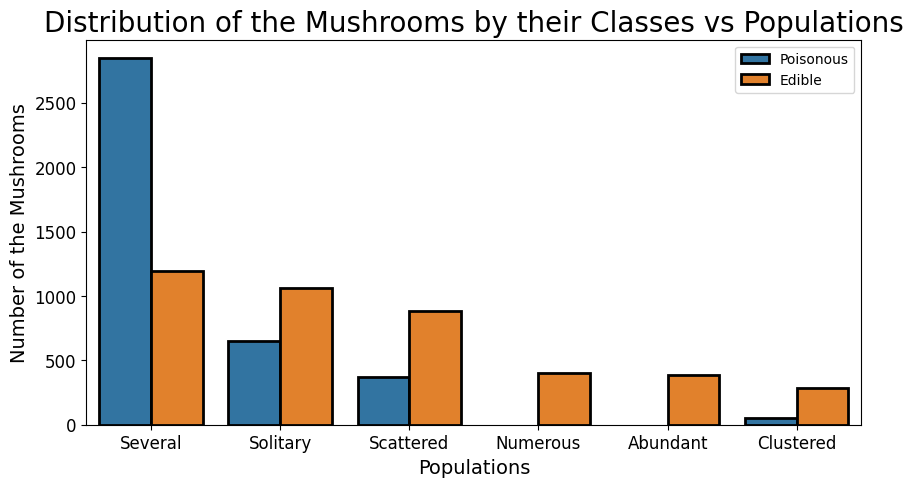

In [54]:
plt.figure(figsize=(10, 5))
splot = sns.countplot(data=data, x='population', hue='class',
                      order=data['population'].value_counts().index,
                      palette=['#1f77b4', '#ff7f0e'],
                      edgecolor=(0, 0, 0), linewidth=2)

splot.set_xticklabels(['Several', 'Solitary', 'Scattered', 'Numerous', 'Abundant', 'Clustered'])

plt.legend(['Poisonous', 'Edible'], loc='upper right')
plt.ylabel('Number of the Mushrooms', fontsize=14)
plt.xlabel('Populations', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title('Distribution of the Mushrooms by their Classes vs Populations', fontsize=20)

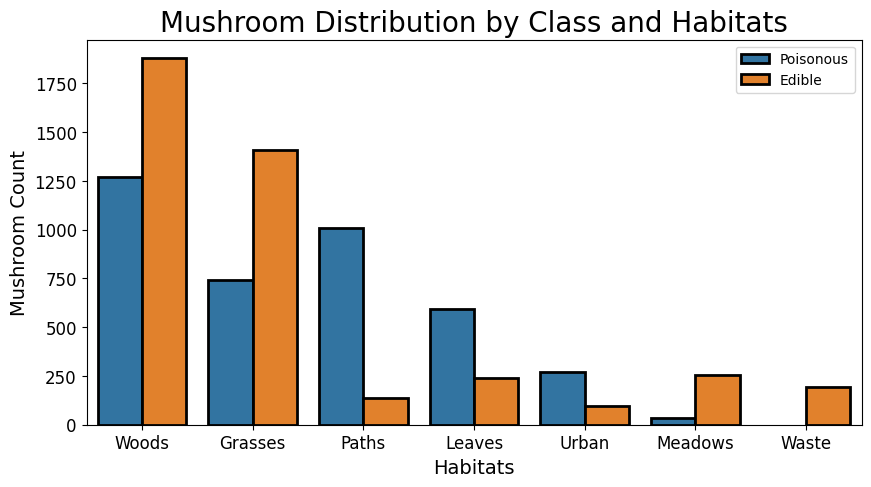

In [55]:
plt.figure(figsize=(10, 5))
splot = sns.countplot(data=data, x='habitat', hue='class',
                      order=data['habitat'].value_counts().index,
                      palette=['#1f77b4', '#ff7f0e'], edgecolor='black', linewidth=2)

splot.set_xticklabels(['Woods', 'Grasses', 'Paths', 'Leaves', 'Urban', 'Meadows', 'Waste'])

plt.legend(['Poisonous', 'Edible'], loc='upper right')
plt.ylabel('Mushroom Count', fontsize=14)
plt.xlabel('Habitats', fontsize=14)
plt.title('Mushroom Distribution by Class and Habitats', fontsize=20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12);

**DATA PREPROCESSING**

In [56]:
count_NAN = data.isna().sum()
count_NAN

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

In [57]:
x = data.drop(['class'],axis = 1)
y = data['class']

In [58]:
x.shape

(8124, 22)

In [59]:
y.shape

(8124,)

In [60]:
y.value_counts()

class
e    4208
p    3916
Name: count, dtype: int64

In [61]:
x.dtypes.value_counts()

str    22
Name: count, dtype: int64

**Label Encoding**

In [68]:
x_enc = x.copy()
for col in x.columns:
    lb = LabelEncoder()
    x_enc[col] = lb.fit_transform(x[col])
y_enc = lb.fit_transform(y)
x_enc.head()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,5,2,4,1,6,1,0,1,4,0,...,2,7,7,0,2,1,4,2,3,5
1,5,2,9,1,0,1,0,0,4,0,...,2,7,7,0,2,1,4,3,2,1
2,0,2,8,1,3,1,0,0,5,0,...,2,7,7,0,2,1,4,3,2,3
3,5,3,8,1,6,1,0,1,5,0,...,2,7,7,0,2,1,4,2,3,5
4,5,2,3,0,5,1,1,0,4,1,...,2,7,7,0,2,1,0,3,0,1


In [67]:
x.head()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,x,s,n,t,p,f,c,n,k,e,...,s,w,w,p,w,o,p,k,s,u
1,x,s,y,t,a,f,c,b,k,e,...,s,w,w,p,w,o,p,n,n,g
2,b,s,w,t,l,f,c,b,n,e,...,s,w,w,p,w,o,p,n,n,m
3,x,y,w,t,p,f,c,n,n,e,...,s,w,w,p,w,o,p,k,s,u
4,x,s,g,f,n,f,w,b,k,t,...,s,w,w,p,w,o,e,n,a,g


In [69]:
y_enc

array([1, 0, 0, ..., 0, 1, 0], shape=(8124,))

**Train-Test Split**

In [71]:
x_train, x_test, y_train, y_test = train_test_split(x_enc, y_enc, test_size = 0.2, random_state = 42)
x_train.head()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
7873,3,2,2,0,7,1,0,1,0,1,...,1,6,7,0,2,1,0,7,4,0
6515,5,2,4,0,2,1,0,1,0,1,...,2,7,7,0,2,1,0,7,4,4
6141,2,3,2,0,8,1,0,1,0,1,...,2,6,7,0,2,1,0,7,4,2
2764,2,0,4,1,5,1,0,0,9,1,...,2,3,6,0,2,1,4,3,4,0
438,0,3,9,1,3,1,0,0,4,0,...,2,7,7,0,2,1,4,3,2,3


In [72]:
x_train.shape

(6499, 22)

**SVM BUILDING**

In [73]:
svc = SVC()
svc.fit(x_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [74]:
svc.score(x_test,y_test)

0.9913846153846154

In [75]:
svc.score(x_train,y_train)

0.9906139406062471